# Inspect Minimal Test SSN

This notebook visualizes the minimal E/I SSN used in `test_run_optimizations.py`
to verify that it has desirable properties:

1. The W matrix structure (E/I sign convention, sparsity)
2. Eigenvalue spectrum of W (stability)
3. Dynamics with non-zero input drive
4. Sensitivity to different input amplitudes

In [1]:
import sys
from pathlib import Path

# Ensure SSN module is importable
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse
from SSN import SSN

## 1. Build the minimal test network

This is the same `_build_minimal_ssn` helper from `test_run_optimizations.py`,
reproduced here so you can tweak parameters interactively.

In [67]:
def build_minimal_ssn(n_e=3, n_i=1, tstop=100.0, dt=0.1):
    """Build a minimal E/I SSN for inspection.
    
    Parameters
    ----------
    n_e : int
        Number of excitatory cells.
    n_i : int
        Number of inhibitory cells.
    tstop : float
        Simulation duration (ms).
    dt : float
        Time step for input vector (ms).
    """
    n_cells = n_e + n_i
    ssn = SSN("inspect_minimal", rand_seed=123, verbose=False)

    ssn.nodes = pd.DataFrame({
        "model_name": ["E"] * n_e + ["I"] * n_i,
        "model_index": [0] * n_e + [1] * n_i,
    })
    ssn.node_types = pd.DataFrame({
        "model_type_id": [0, 1],
        "tau": [20.0, 10.0],
        "k": [0.04, 0.04],
        "c": [1.0, 1.0],
        "n": [2.0, 2.0],
    })

    # Recurrent weight matrix
    W = np.zeros((n_cells, n_cells))
    # Set weights
    W[:n_e, n_e:] = -0.170  # I->E inhibition
    W[n_e:, :n_e] = 0.093   # E->I excitation
    W[:n_e, :n_e] += 0.178  # E->E excitation
    W[n_e:, n_e:] += -0.073  # I->I inhibition
    ssn._W_dense = W  # stash for inspection
    ssn.construct_W = lambda: W

    # Input current h(t) -- placeholder, overridden below
    t_arr = np.arange(0, tstop, dt)
    ssn.h = np.zeros((n_cells, len(t_arr)), dtype=float)

    ssn.stim_params = {
        "temporal": {"params": {"T": tstop, "t_steps": dt}},
    }
    ssn.run_params = {
        "tstop": tstop,
        "dt": dt,
        "r_init": {"type": "uniform", "E": 0.0, "I": 0.0},
        "method": "RK45",
    }
    return ssn, W, t_arr

In [68]:
# ------- Adjustable parameters -------
N_E = 2
N_I = 2
TSTOP = 100.0   # ms
DT = 0.1        # ms
# --------------------------------------

ssn, W, t_arr = build_minimal_ssn(n_e=N_E, n_i=N_I, tstop=TSTOP, dt=DT)
n_cells = N_E + N_I

print(f"Network: {N_E}E + {N_I}I = {n_cells} cells")
print(f"Simulation: {TSTOP} ms, dt={DT} ms ({len(t_arr)} time points)")
print(f"\nNode types:")
display(ssn.node_types)
print(f"\nNodes:")
display(ssn.nodes)

Network: 2E + 2I = 4 cells
Simulation: 100.0 ms, dt=0.1 ms (1000 time points)

Node types:


,model_type_id,tau,k,c,n
0,0,20.0,0.04,1.0,2.0
1,1,10.0,0.04,1.0,2.0



Nodes:


,model_name,model_index
0,E,0
1,E,0
2,I,1
3,I,1


## 2. Inspect the W matrix

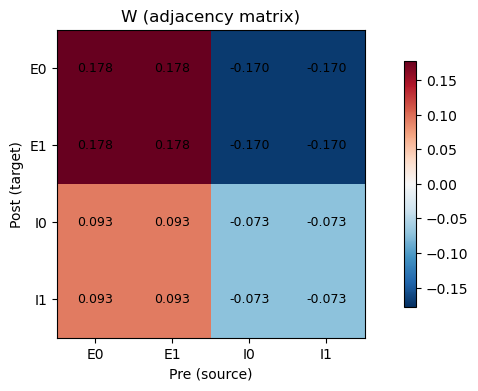

In [69]:
fig, axes = plt.subplots(figsize=(10, 4))

# Heatmap of W
labels = [f"E{i}" for i in range(N_E)] + [f"I{i}" for i in range(N_I)]
im = axes.imshow(W, cmap='RdBu_r', vmin=-np.max(np.abs(W)), vmax=np.max(np.abs(W)))
axes.set_xticks(range(n_cells))
axes.set_xticklabels(labels)
axes.set_yticks(range(n_cells))
axes.set_yticklabels(labels)
axes.set_xlabel('Pre (source)')
axes.set_ylabel('Post (target)')
axes.set_title('W (adjacency matrix)')
plt.colorbar(im, ax=axes, shrink=0.8)

# Annotate cell values
for i in range(n_cells):
    for j in range(n_cells):
        if W[i, j] != 0:
            axes.text(j, i, f'{W[i,j]:.3f}', ha='center', va='center', fontsize=9)

## 3. Run with non-zero input drive

We test several input amplitudes to verify:
- Rates grow with input (non-trivial dynamics)
- The network is stable (rates don't diverge)
- E and I cells behave differently (different tau, n)

In [70]:
# Define a set of input amplitudes to test
input_amplitudes = np.logspace(-1, 2, 10)

results = {}  # amplitude -> (t, y)

for amp in input_amplitudes:
    ssn_run, W_run, t_run = build_minimal_ssn(n_e=N_E, n_i=N_I, tstop=TSTOP, dt=DT)
    # Step input: constant amplitude for all cells
    ssn_run.h = np.ones((n_cells, len(t_run))) * amp
    ssn_run.run()
    results[amp] = (ssn_run.outputs.t, ssn_run.outputs.y)
    status = "OK" if ssn_run.outputs.success else "FAILED"
    peak = np.max(ssn_run.outputs.y)
    print(f"  amp={amp:5.1f}  status={status}  peak_rate={peak:.4f}  nfev={ssn_run.outputs.nfev}")

  amp=  0.1  status=OK  peak_rate=0.0004  nfev=68
  amp=  0.2  status=OK  peak_rate=0.0019  nfev=74
  amp=  0.5  status=OK  peak_rate=0.0086  nfev=74
  amp=  1.0  status=OK  peak_rate=0.0401  nfev=74
  amp=  2.2  status=OK  peak_rate=0.1868  nfev=80
  amp=  4.6  status=OK  peak_rate=0.8730  nfev=80
  amp= 10.0  status=OK  peak_rate=4.1037  nfev=80
  amp= 21.5  status=OK  peak_rate=19.3095  nfev=80
  amp= 46.4  status=OK  peak_rate=83.8496  nfev=80
  amp=100.0  status=OK  peak_rate=258.5011  nfev=86


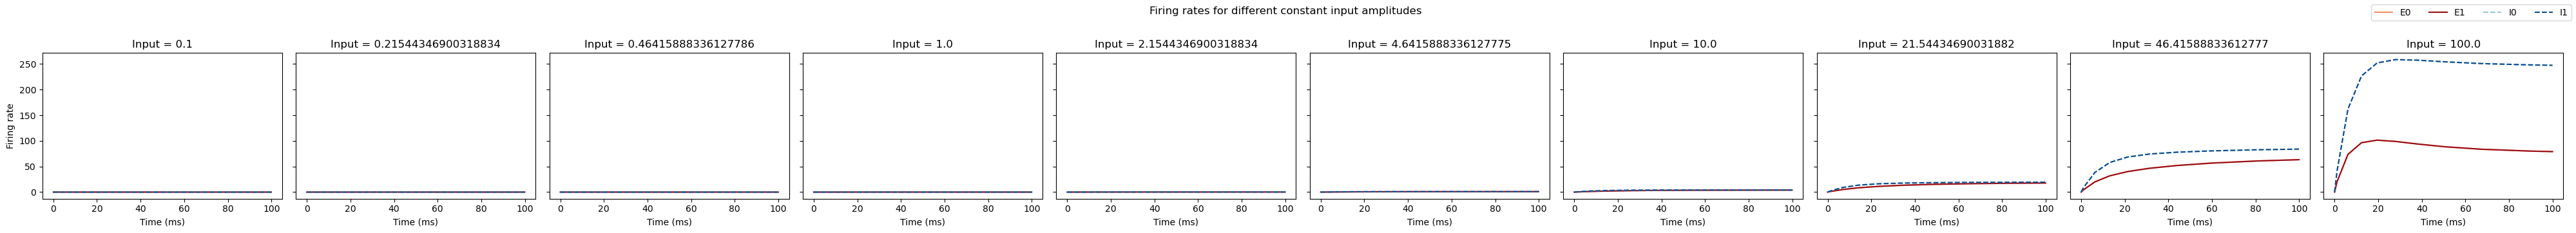

In [71]:
n_amps = len(input_amplitudes)
fig, axes = plt.subplots(1, n_amps, figsize=(4 * n_amps, 3.5), sharey=True)
if n_amps == 1:
    axes = [axes]

colors_e = plt.cm.Reds(np.linspace(0.4, 0.9, N_E))
colors_i = plt.cm.Blues(np.linspace(0.4, 0.9, N_I))

for ax, amp in zip(axes, input_amplitudes):
    t_out, y_out = results[amp]
    for i in range(N_E):
        ax.plot(t_out, y_out[i], color=colors_e[i], label=f'E{i}' if amp == input_amplitudes[0] else None)
    for i in range(N_I):
        ax.plot(t_out, y_out[N_E + i], color=colors_i[i], linestyle='--',
                label=f'I{i}' if amp == input_amplitudes[0] else None)
    ax.set_title(f'Input = {amp}')
    ax.set_xlabel('Time (ms)')
    if ax == axes[0]:
        ax.set_ylabel('Firing rate')

# Legend from first panel
handles = []
for i in range(N_E):
    handles.append(plt.Line2D([0], [0], color=colors_e[i], label=f'E{i}'))
for i in range(N_I):
    handles.append(plt.Line2D([0], [0], color=colors_i[i], linestyle='--', label=f'I{i}'))
fig.legend(handles=handles, loc='upper right', ncol=N_E + N_I)

plt.suptitle('Firing rates for different constant input amplitudes', y=1.02)
plt.tight_layout()
plt.show()

## 4. Steady-state input-output curve (f-I curve)

Plot the steady-state firing rate at the end of the simulation as a function
of input amplitude. This shows whether the power-law nonlinearity is producing
the expected supralinear input-output relationship.

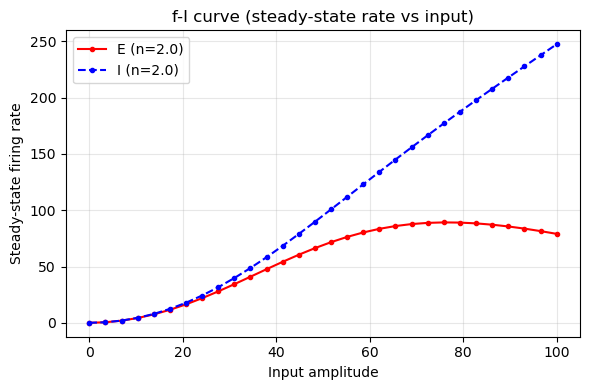

Expect supralinear (accelerating) shape due to power-law f(x) = k * max(x, 0)^n


In [72]:
# Finer sweep of input amplitudes for f-I curve
fi_amps = np.linspace(0, 100, 30)
fi_rates_E = []  # mean across E cells
fi_rates_I = []  # mean across I cells

for amp in fi_amps:
    ssn_fi, _, t_fi = build_minimal_ssn(n_e=N_E, n_i=N_I, tstop=TSTOP, dt=DT)
    ssn_fi.h = np.ones((n_cells, len(t_fi))) * amp
    ssn_fi.run()
    # Take last 10% of output as "steady state"
    n_ss = max(1, int(0.1 * len(ssn_fi.outputs.t)))
    y_ss = ssn_fi.outputs.y[:, -n_ss:].mean(axis=1)
    fi_rates_E.append(y_ss[:N_E].mean())
    fi_rates_I.append(y_ss[N_E:].mean())

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fi_amps, fi_rates_E, 'r.-', label=f'E (n={ssn.node_types.iloc[0]["n"]:.1f})')
ax.plot(fi_amps, fi_rates_I, 'b.--', label=f'I (n={ssn.node_types.iloc[1]["n"]:.1f})')
ax.set_xlabel('Input amplitude')
ax.set_ylabel('Steady-state firing rate')
ax.set_title('f-I curve (steady-state rate vs input)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Expect supralinear (accelerating) shape due to power-law f(x) = k * max(x, 0)^n")

## 5. Time-varying input (transient response)

Test with a pulse input to see transient dynamics and verify the
network relaxes back to zero.

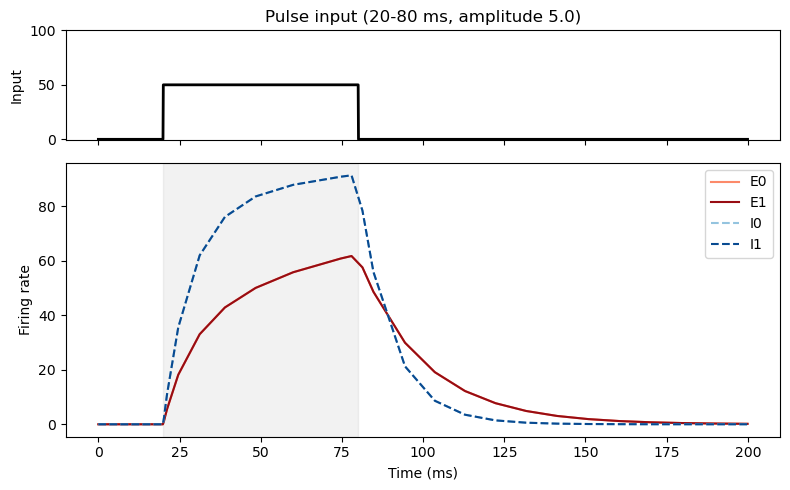

Final rates (should be near zero): [0.16473975 0.16473975 0.0008762  0.0008762 ]
Max |final rate|: 0.164740


In [74]:
ssn_pulse, _, t_pulse = build_minimal_ssn(n_e=N_E, n_i=N_I, tstop=200.0, dt=DT)

# Create a pulse: on from 20-80 ms, amplitude 5.0
h_pulse = np.zeros((n_cells, len(t_pulse)))
pulse_on = (t_pulse >= 20) & (t_pulse <= 80)
h_pulse[:, pulse_on] = 50.0
ssn_pulse.h = h_pulse
ssn_pulse.stim_params["temporal"]["params"]["T"] = 200.0
ssn_pulse.run_params["tstop"] = 200.0

ssn_pulse.run()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                                gridspec_kw={'height_ratios': [1, 2.5]})

# Input
ax1.plot(t_pulse, h_pulse[0], 'k-', lw=2)
ax1.set_ylabel('Input')
ax1.set_title('Pulse input (20-80 ms, amplitude 5.0)')
ax1.set_ylim(-0.5, 100)

# Output rates
t_out = ssn_pulse.outputs.t
y_out = ssn_pulse.outputs.y
for i in range(N_E):
    ax2.plot(t_out, y_out[i], color=colors_e[i], label=f'E{i}')
for i in range(N_I):
    ax2.plot(t_out, y_out[N_E + i], color=colors_i[i], linestyle='--', label=f'I{i}')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Firing rate')
ax2.legend()
ax2.axvspan(20, 80, alpha=0.1, color='gray')

plt.tight_layout()
plt.show()

# Check: after pulse ends, rates should decay toward zero
final_rates = y_out[:, -1]
print(f"Final rates (should be near zero): {final_rates}")
print(f"Max |final rate|: {np.max(np.abs(final_rates)):.6f}")

# 6. Check Stability

Solve for the Jacobian and look at the real parts of the eigenvalues.

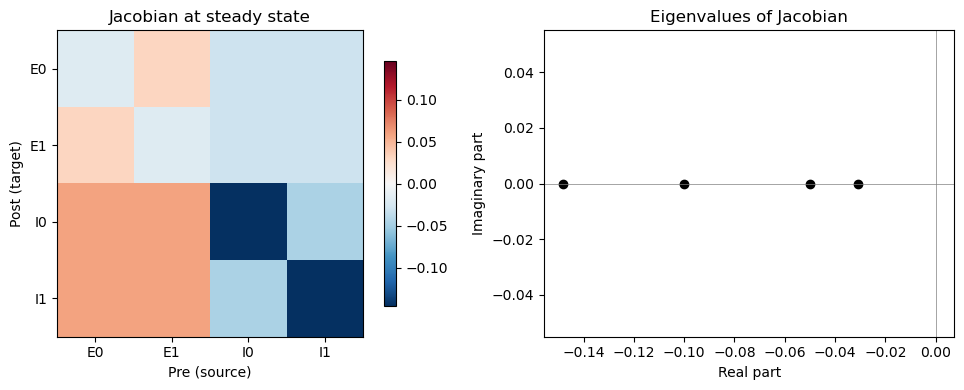

Steady state is stable (max real part of eigenvalues = -0.0308 < 0)


In [79]:
# Run model with constant input at 100
ssn_const, W, t_const = build_minimal_ssn(n_e=N_E, n_i=N_I, tstop=TSTOP, dt=DT)
ssn_const.h = np.ones((n_cells, len(t_const))) * 100.
ssn_const.run()

# Store final time points as steady state
steady_state_rates = ssn_const.outputs.y[:, -1]

# Solve for effective gain matrix D
c = ssn_const.node_types.loc[ssn_const.nodes["model_index"], "c"].values
i_arg = W @ steady_state_rates + c * ssn_const.h[:, -1]
k = ssn_const.node_types.loc[ssn_const.nodes["model_index"], "k"].values
n = ssn_const.node_types.loc[ssn_const.nodes["model_index"], "n"].values
D = k * n * np.maximum(i_arg, 0) ** (n - 1)

# Jacobian
tau = ssn_const.node_types.loc[ssn_const.nodes["model_index"], "tau"].values
J = (1.0 / tau)[:, None] * (D[:, None] * W - np.eye(n_cells))

# Plot Jacobian and eigenvalues on Re-Im plane
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
im = ax1.imshow(J, cmap='RdBu_r', vmin=-np.max(np.abs(J)), vmax=np.max(np.abs(J)))
ax1.set_title('Jacobian at steady state')
ax1.set_xlabel('Pre (source)')
ax1.set_ylabel('Post (target)')
ax1.set_xticks(range(n_cells))
ax1.set_xticklabels(labels)
ax1.set_yticks(range(n_cells))
ax1.set_yticklabels(labels)
plt.colorbar(im, ax=ax1, shrink=0.8)
eigenvalues = np.linalg.eigvals(J)
ax2.plot(eigenvalues.real, eigenvalues.imag, 'ko')
ax2.axhline(0, color='gray', lw=0.5)
ax2.axvline(0, color='gray', lw=0.5)
ax2.set_xlabel('Real part')
ax2.set_ylabel('Imaginary part')
ax2.set_title('Eigenvalues of Jacobian')
plt.tight_layout()
plt.show()

# Print stability info by checking the largest real part of eigenvalues
max_real_part = np.max(eigenvalues.real)
if max_real_part < 0:
    print(f"Steady state is stable (max real part of eigenvalues = {max_real_part:.4f} < 0)")
elif max_real_part > 0:
    print(f"Steady state is unstable (max real part of eigenvalues = {max_real_part:.4f} > 0)")
else:
    print(f"Steady state is marginally stable (max real part of eigenvalues = {max_real_part:.4f} = 0)")